In [2]:
import glob

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import xarray as xr
import xclim as xc
import numpy as np
import cmocean
import geopandas as gp

from unseen import fileio

## Shapefile

In [3]:
#river_regions_file = '/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/river_regions/river_regions.shp'
#river_regions = gp.read_file(river_regions_file)

In [4]:
#river_regions['Division'].unique()

In [5]:
#sec_river_regions = river_regions[river_regions['Division'] == 'South East Coast (NSW)']
#sec_river_regions

In [45]:
lgas_file = '/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/aus_local_gov/aus_local_gov.shp'
lgas = gp.read_file(lgas_file)

In [46]:
nsw_lgas = lgas[lgas['STE_NAME21'] == 'New South Wales']

In [47]:
nsw_lgas['LGA_NAME22'].unique()

array(['Albury', 'Armidale', 'Ballina', 'Balranald', 'Bathurst',
       'Bayside (NSW)', 'Bega Valley', 'Bellingen', 'Berrigan',
       'Blacktown', 'Bland', 'Blayney', 'Blue Mountains', 'Bogan',
       'Bourke', 'Brewarrina', 'Broken Hill', 'Burwood', 'Byron',
       'Cabonne', 'Camden', 'Campbelltown (NSW)', 'Canada Bay',
       'Canterbury-Bankstown', 'Carrathool', 'Central Coast (NSW)',
       'Central Darling', 'Cessnock', 'Clarence Valley', 'Cobar',
       'Coffs Harbour', 'Coolamon', 'Coonamble', 'Cootamundra-Gundagai',
       'Cowra', 'Cumberland', 'Dubbo', 'Dungog', 'Edward River',
       'Eurobodalla', 'Fairfield', 'Federation', 'Forbes',
       'Georges River', 'Gilgandra', 'Glen Innes Severn',
       'Goulburn Mulwaree', 'Greater Hume', 'Griffith', 'Gunnedah',
       'Gwydir', 'Hawkesbury', 'Hay', 'Hilltops', 'Hornsby',
       'Hunters Hill', 'Inner West', 'Inverell', 'Junee', 'Kempsey',
       'Kiama', 'Ku-ring-gai', 'Kyogle', 'Lachlan', 'Lake Macquarie',
       'Lane Cove

In [48]:
newcastle_lgas = ['Newcastle', 'Port Stephens', 'Maitland', 'Cessnock', 'Lake Macquarie']
greater_newcastle = nsw_lgas[nsw_lgas['LGA_NAME22'].isin(newcastle_lgas)]

In [49]:
greater_newcastle

,LGA_CODE22,LGA_NAME22,STE_CODE21,STE_NAME21,AREASQKM,LOCI_URI21,SHAPE_Leng,SHAPE_Area,geometry
27,11720,Cessnock,1,New South Wales,1965.1593,https://linked.data.gov.au/dataset/asgsed3/LGA...,2.982206,0.189450,"POLYGON ((151.15081 -32.81308, 151.15208 -32.8..."
64,14650,Lake Macquarie,1,New South Wales,648.6393,https://linked.data.gov.au/dataset/asgsed3/LGA...,3.050710,0.062611,"MULTIPOLYGON (((151.64029 -33.05817, 151.64014..."
72,15050,Maitland,1,New South Wales,391.5089,https://linked.data.gov.au/dataset/asgsed3/LGA...,1.210587,0.037654,"POLYGON ((151.64284 -32.71946, 151.64328 -32.7..."
84,15900,Newcastle,1,New South Wales,186.7255,https://linked.data.gov.au/dataset/asgsed3/LGA...,1.269069,0.017992,"MULTIPOLYGON (((151.76983 -32.90087, 151.7698 ..."
93,16400,Port Stephens,1,New South Wales,858.4357,https://linked.data.gov.au/dataset/asgsed3/LGA...,2.965041,0.082571,"MULTIPOLYGON (((152.12398 -32.78479, 152.12399..."


In [50]:
greater_newcastle = greater_newcastle.dissolve()
greater_newcastle['LGA_NAME22'][0] = 'Greater Newcastle'
greater_newcastle.to_file('/g/data/xv83/unseen-projects/outputs/pasha/shapefiles/greater_newcastle.shp')

/jobfs/148388387.gadi-pbs/ipykernel_1498580/4109879283.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  greater_newcastle['LGA_NAME22'][0] = 'Greater Newcastle'
/jobfs/148388387.gadi-pbs/ipykernel_1498580/4109879283.py:2: SettingWithCopyW

In [51]:
greater_newcastle

,geometry,LGA_CODE22,LGA_NAME22,STE_CODE21,STE_NAME21,AREASQKM,LOCI_URI21,SHAPE_Leng,SHAPE_Area
0,"MULTIPOLYGON (((151.65394 -33.09354, 151.65364...",11720,Greater Newcastle,1,New South Wales,1965.1593,https://linked.data.gov.au/dataset/asgsed3/LGA...,2.982206,0.18945


In [52]:
pasha_lgas = newcastle_lgas + ['Central Coast (NSW)',]
pasha_area = nsw_lgas[nsw_lgas['LGA_NAME22'].isin(pasha_lgas)]
pasha_area = pasha_area.dissolve()
pasha_area['LGA_NAME22'][0] = 'Pasha Bulker LGAs'
pasha_area.to_file('/g/data/xv83/unseen-projects/outputs/pasha/shapefiles/pasha_area.shp')

/jobfs/148388387.gadi-pbs/ipykernel_1498580/4240877637.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pasha_area['LGA_NAME22'][0] = 'Pasha Bulker LGAs'
/jobfs/148388387.gadi-pbs/ipykernel_1498580/4240877637.py:4: SettingWithCopyWarning:

In [53]:
pasha_area

,geometry,LGA_CODE22,LGA_NAME22,STE_CODE21,STE_NAME21,AREASQKM,LOCI_URI21,SHAPE_Leng,SHAPE_Area
0,"MULTIPOLYGON (((151.31498 -33.55568, 151.31498...",11650,Pasha Bulker LGAs,1,New South Wales,1681.0059,https://linked.data.gov.au/dataset/asgsed3/LGA...,5.261147,0.162751


## Day-by-day rainfall

In [22]:
agcd_file = '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_20070101-20071231_daily.nc'

In [23]:
ds = xr.open_dataset(agcd_file)

/jobfs/148388387.gadi-pbs/ipykernel_1498580/762140172.py:10: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in p.axes.flat:


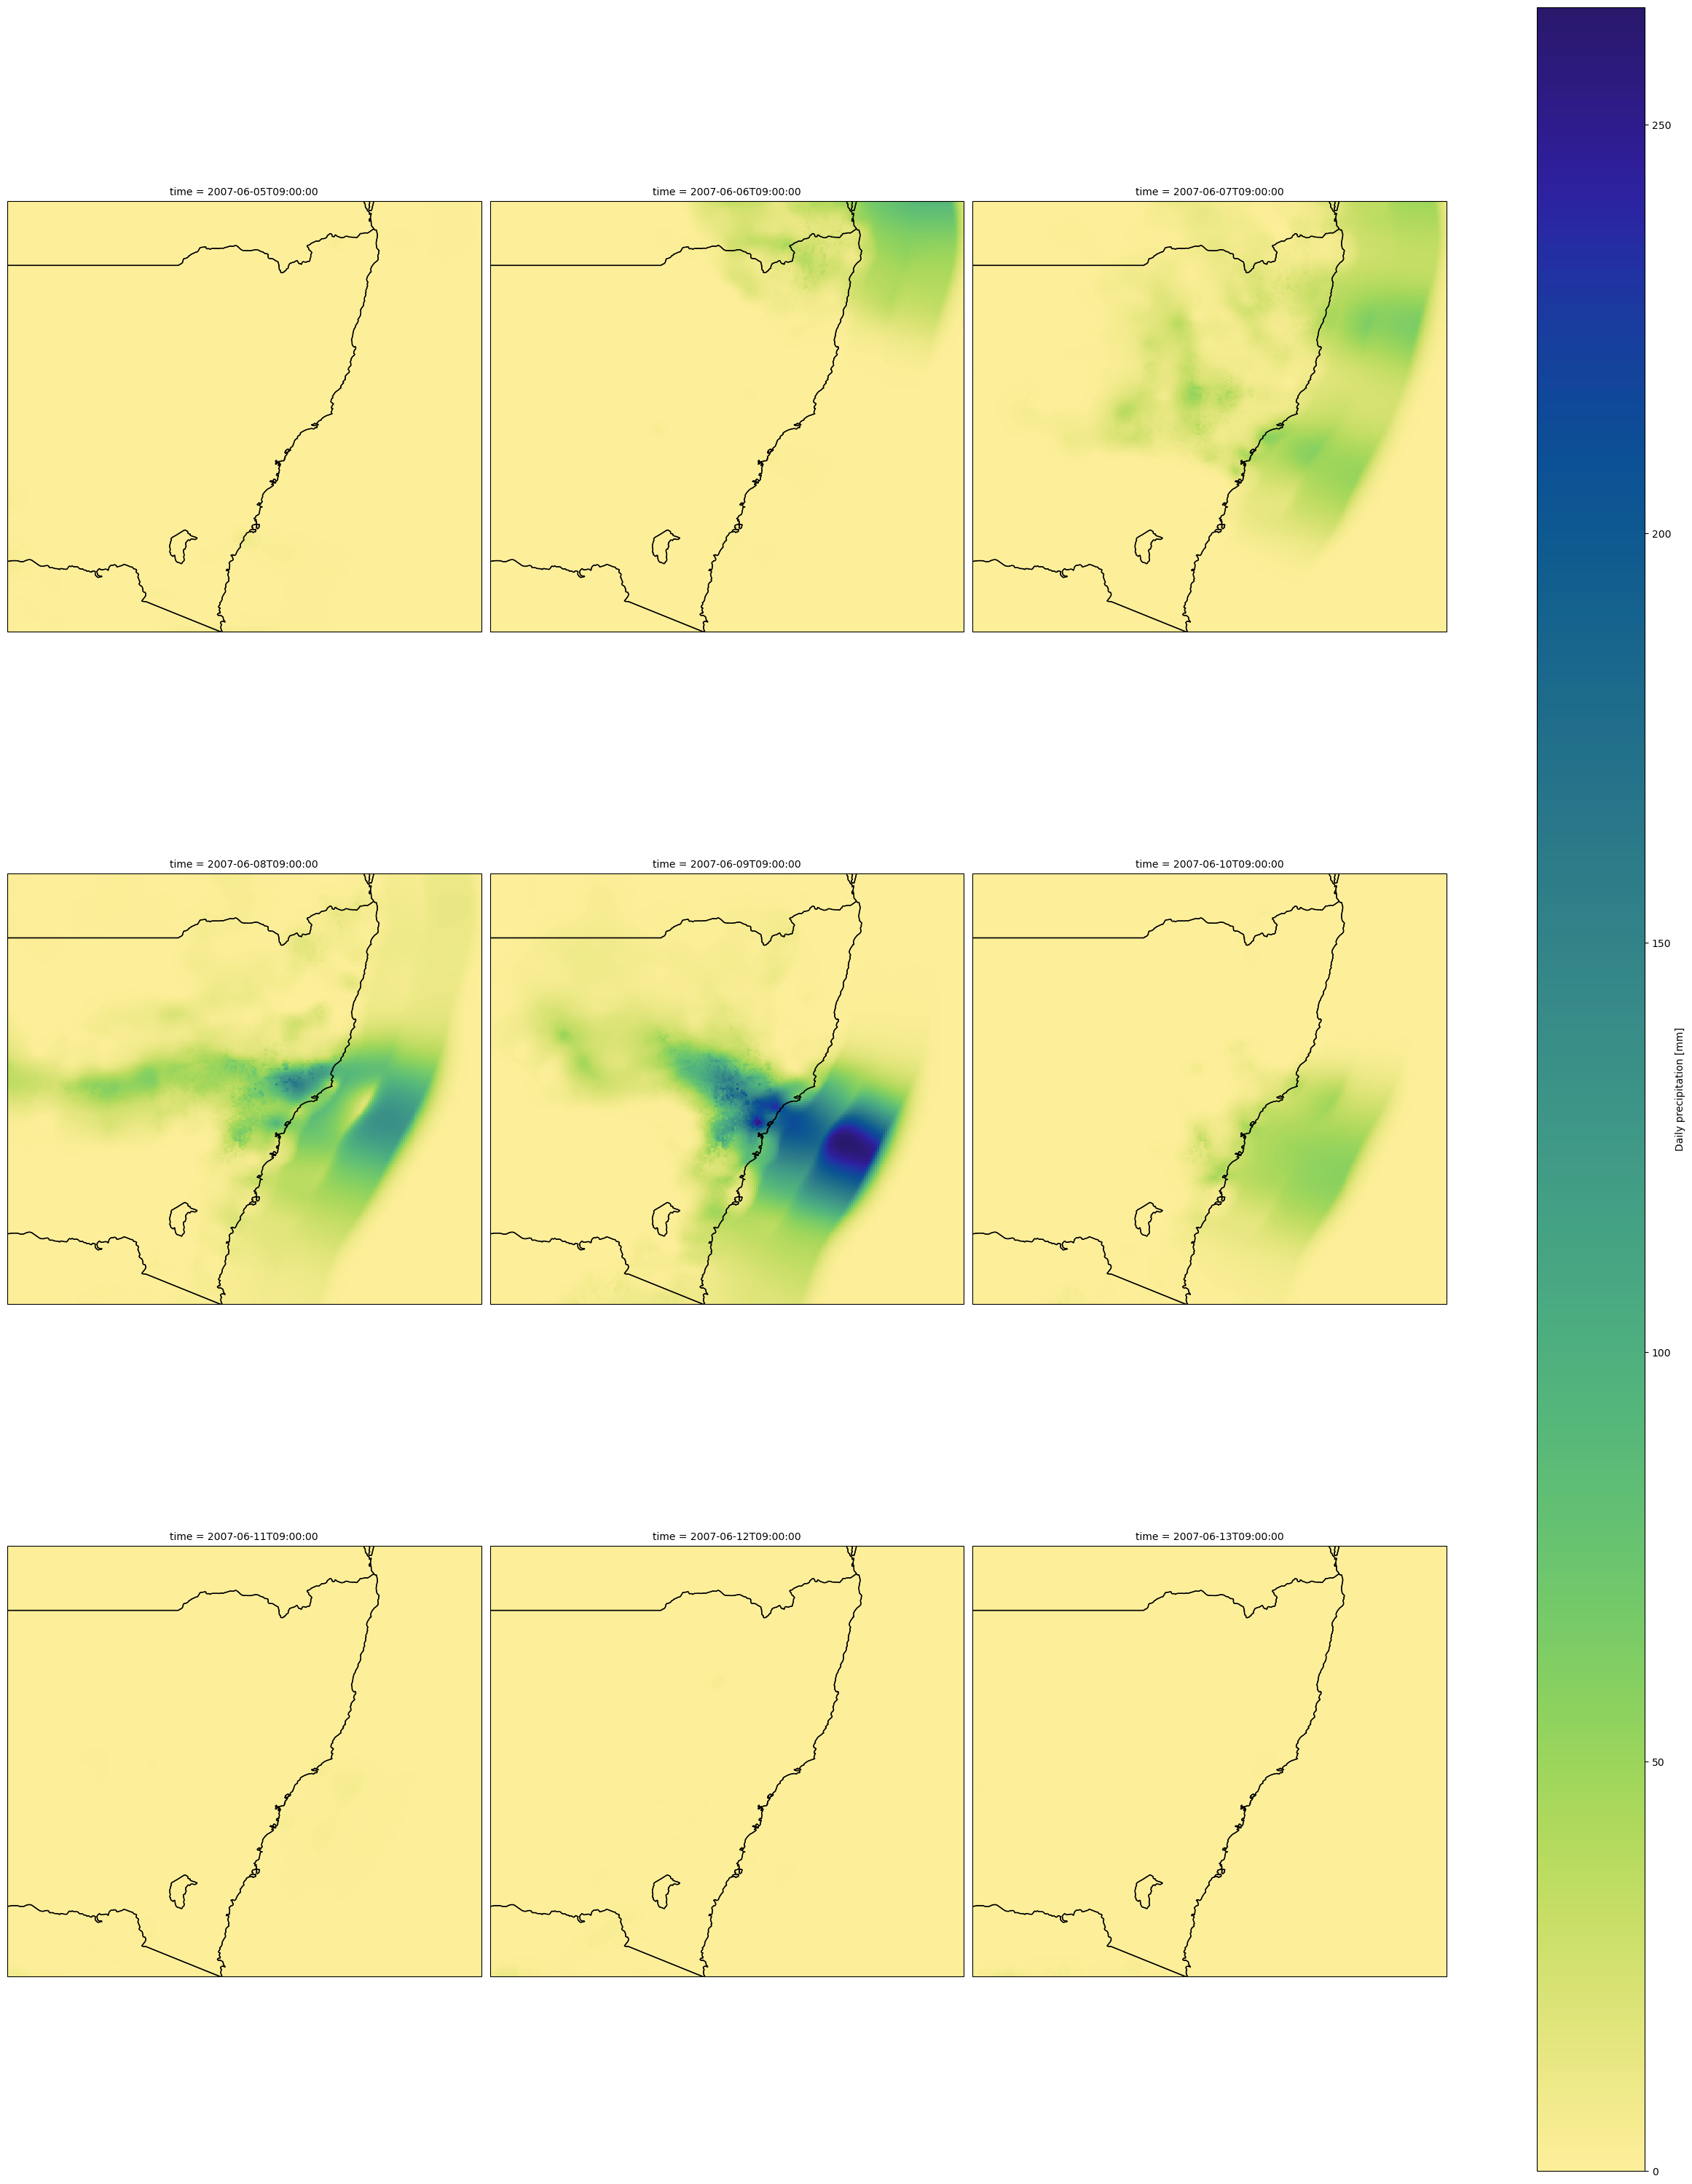

In [24]:
p = ds['precip'].sel(time=slice('2007-06-05', '2007-06-13')).plot(
    col='time',
    col_wrap=3,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.haline_r,
    figsize=[25, 30],
    subplot_kws={"projection": ccrs.PlateCarree()},
)

for ax in p.axes.flat:
    ax.coastlines()
    ax.add_feature(cartopy.feature.STATES)
    ax.set_extent([145, 156, -27.5, -37.5], crs=ccrs.PlateCarree())

#plt.savefig(
#    'jasper_day-by-day.png',
#    bbox_inches='tight',
#    facecolor='white',
#    dpi=100
#)
plt.show()

## Event summary

In [26]:
ds_masked = fileio.open_dataset(
    agcd_file,
    shapefile='/g/data/ia39/aus-ref-clim-data-nci/shapefiles/data/australia/australia.shp'
)
precip_total_masked = ds_masked['precip'].sel(time=slice('2007-06-08', '2007-06-09')).sum(dim=['time'], min_count=1)

In [34]:
def plot_cities(ax, label_color='white'):
    lats = [-32.9, -33.9]
    lons = [151.8, 151.2]
    cities = ['Newcastle', 'Sydney']
    for lon, lat, city in zip(lons, lats, cities):
        ax.plot(lon, lat, 'ro', zorder=5, transform=ccrs.PlateCarree())
        ax.text(
            lon + 0.12,
            lat - 0.04,
            city,
            fontsize='large',
            color=label_color,
            transform=ccrs.PlateCarree()
        )

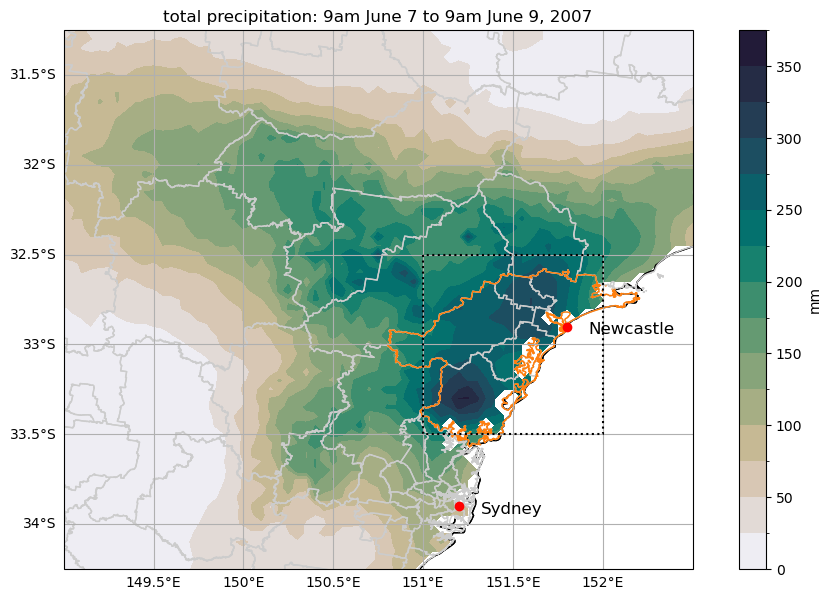

In [41]:
fig = plt.figure(figsize=[12, 7])
ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
lw = 1.0
pr_levels = np.arange(0, 400, 25)
cmap = cmocean.cm.rain
# cmocean.cm.haline_r

precip_total_masked.plot.contourf(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    levels=pr_levels,
    cbar_kwargs={'label': 'mm'},
)
ax1.coastlines()

# State boundaries
ax1.add_feature(cartopy.feature.STATES)

# River catchment boundaries 
#ax1.add_geometries(
#    sec_river_regions.geometry,
#    ccrs.PlateCarree(),
#    facecolor='none',
#    linewidth=lw,
#    edgecolor='tab:cyan',
#)
#ax1.add_geometries(
#    sec_river_regions[sec_river_regions['RivRegName'] == 'HUNTER RIVER'].geometry,
#    ccrs.PlateCarree(),
#    facecolor='none',
#    linewidth=lw,
#    edgecolor='tab:cyan',
#)
#ax1.add_geometries(
#    sec_river_regions[sec_river_regions['RivRegName'] == 'MACQUARIE-TUGGERAH LAKES'].geometry,
#    ccrs.PlateCarree(),
#    facecolor='none',
#    linewidth=lw,
#    edgecolor='tab:cyan',
#)

# Local government areas
ax1.add_geometries(
    nsw_lgas.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    linewidth=lw,
    edgecolor='0.8',
)

ax1.add_geometries(
    pasha_area.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    linewidth=lw,
    edgecolor='tab:orange',
)

gl = ax1.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
ax1.plot(
    [151, 151, 152, 152, 151],
    [-32.5, -33.5, -33.5, -32.5, -32.5],
    transform=ccrs.PlateCarree(),
    color='black',
    linestyle=':'
)

ax1.set_extent([149, 152.5, -31.25, -34.25], crs=ccrs.PlateCarree())
plot_cities(ax1, label_color='black')
ax1.set_title('total precipitation: 9am June 7 to 9am June 9, 2007')

plt.savefig(
    'pasha_event.png',
    bbox_inches='tight',
    facecolor='white',
    dpi=300
)
plt.show()

In [42]:
agcd_files = sorted(glob.glob('/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_*_daily.nc'))

In [44]:
agcd_files

['/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19000101-19001231_daily.nc',
 '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19010101-19011231_daily.nc',
 '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19020101-19021231_daily.nc',
 '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19030101-19031231_daily.nc',
 '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19040101-19041231_daily.nc',
 '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19050101-19051231_daily.nc',
 '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19060101-19061231_daily.nc',
 '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19070101-19071231_daily.nc',
 '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19080101-19081231_daily.nc',
 '/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_19090101-19091231_daily.nc',
 '/g/data/xv83/agcd-csiro/prec

In [ ]:
ds = fileio.open_dataset(
    agcd_files,
    variables=['precip',],
    lat_bnds=[-34, -32],
    lon_bnds=[150, 153],
    
    
    